
# Reinforcement Learning Demo: Warehouse Grid Robot (Step-by-Step with Visualization)

This notebook helps you understand how a warehouse robot can learn to navigate to a target location using **Q-learning**.  
You'll see every action the robot takes and how its decisions improve over time.

We visualize the robot's movement on a 5x5 grid in each step!


### 🔹 Initialize Agent and Q-Table
This cell initializes the learning rate, discount factor, number of episodes, and the Q-table which will store the value of actions in each state. The robot starts with zero knowledge.

In [1]:
import matplotlib.patches as patches

import numpy as np
import matplotlib.pyplot as plt
import random

class GridWorld:
    def __init__(self, size=5, goal=(4, 4)):
        self.size = size
        self.goal = goal
        self.reset()

    def reset(self):
        self.agent_pos = [0, 0]
        return tuple(self.agent_pos)

    def step(self, action):
        if action == 0:
            self.agent_pos[0] = max(self.agent_pos[0] - 1, 0)
        elif action == 1:
            self.agent_pos[0] = min(self.agent_pos[0] + 1, self.size - 1)
        elif action == 2:
            self.agent_pos[1] = max(self.agent_pos[1] - 1, 0)
        elif action == 3:
            self.agent_pos[1] = min(self.agent_pos[1] + 1, self.size - 1)

        done = (tuple(self.agent_pos) == self.goal)
        reward = 1 if done else -0.01
        return tuple(self.agent_pos), reward, done

    def render(self):
        grid = np.full((self.size, self.size), ' ')
        grid[self.goal] = 'G'
        grid[tuple(self.agent_pos)] = 'R'
        for row in grid:
            print(' '.join(row))
        print()


### 🔹 View Initial Q-Values
This prints the initial Q-values for the 'UP' action (index 0). All values are 0 since the agent hasn't learned anything yet.

In [32]:

env = GridWorld()
q_table = np.zeros((env.size, env.size, 4))
learning_rate = 0.1
discount_factor = 0.95
epsilon = 0.3
episodes = 50
reward_per_episode = []


### 🔹 Step-by-Step Visualization of One Episode
This runs one episode interactively, step-by-step. After each move, it prints the action, reward, and updated Q-value, along with a visual grid showing the robot’s location.

In [33]:

print("Initial Q-table (for 'Up' action only):")
print(q_table[:, :, 0])


Initial Q-table (for 'Up' action only):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


### 🔹 Full Training Loop (Multiple Episodes)
Here, we train the agent over many episodes. The robot explores the environment, updates Q-values based on rewards, and improves its navigation policy.

In [34]:

state = env.reset()
done = False
print("Episode 1 begins:")
env.render()

while not done:
    if random.uniform(0, 1) < epsilon:
        action = random.randint(0, 3)
    else:
        action = np.argmax(q_table[state[0], state[1]])

    next_state, reward, done = env.step(action)

    old_value = q_table[state[0], state[1], action]
    next_max = np.max(q_table[next_state[0], next_state[1]])
    new_value = (1 - learning_rate) * old_value + learning_rate * (reward + discount_factor * next_max)
    q_table[state[0], state[1], action] = new_value

    print(f"Moved to {next_state}, Reward: {reward:.2f}, Q-value updated from {old_value:.2f} to {new_value:.2f}")
    env.render()

    state = next_state


Episode 1 begins:
R        
         
         
         
        G

Moved to (0, 0), Reward: -0.01, Q-value updated from 0.00 to -0.00
R        
         
         
         
        G

Moved to (1, 0), Reward: -0.01, Q-value updated from 0.00 to -0.00
         
R        
         
         
        G

Moved to (0, 0), Reward: -0.01, Q-value updated from 0.00 to -0.00
R        
         
         
         
        G

Moved to (0, 0), Reward: -0.01, Q-value updated from 0.00 to -0.00
R        
         
         
         
        G

Moved to (0, 0), Reward: -0.01, Q-value updated from -0.00 to -0.00
R        
         
         
         
        G

Moved to (0, 1), Reward: -0.01, Q-value updated from 0.00 to -0.00
  R      
         
         
         
        G

Moved to (0, 1), Reward: -0.01, Q-value updated from 0.00 to -0.00
  R      
         
         
         
        G

Moved to (1, 1), Reward: -0.01, Q-value updated from 0.00 to -0.00
         
  R      
         
       

### 🔹 Show Final Learned Policy
This converts the Q-table into a policy grid using arrows (↑ ↓ ← →), indicating the best action from each cell based on learned values. 'G' marks the goal.

In [35]:
# Train over multiple episodes with logging
for ep in range(episodes):
    state = env.reset()
    done = False
    total_reward = 0

    while not done:
        # Choose action using epsilon-greedy strategy
        if random.uniform(0, 1) < epsilon:
            action = random.randint(0, 3)
        else:
            action = np.argmax(q_table[state[0], state[1]])

        # Step and learn
        next_state, reward, done = env.step(action)
        total_reward += reward

        # Q-value update
        old_value = q_table[state[0], state[1], action]
        next_max = np.max(q_table[next_state[0], next_state[1]])
        new_value = (1 - learning_rate) * old_value + learning_rate * (reward + discount_factor * next_max)
        q_table[state[0], state[1], action] = new_value

        state = next_state

    reward_per_episode.append(total_reward)

    # Print status every 10 episodes
    if (ep + 1) % 10 == 0:
        print(f"Episode {ep + 1}: Total Reward = {total_reward:.2f}")


Episode 10: Total Reward = 0.62
Episode 20: Total Reward = 0.58
Episode 30: Total Reward = 0.90
Episode 40: Total Reward = 0.85
Episode 50: Total Reward = 0.85


### 🔹 Plot Rewards Over Episodes
This plots total reward per episode, showing the robot’s improvement as it learns more efficient paths to the goal.

In [36]:

policy_grid = np.full((env.size, env.size), ' ')
arrows = ['↑', '↓', '←', '→']
for i in range(env.size):
    for j in range(env.size):
        best_action = np.argmax(q_table[i, j])
        policy_grid[i, j] = arrows[best_action]
policy_grid[env.goal] = 'G'
print("Final Learned Policy:")
print(policy_grid)


Final Learned Policy:
[['↓' '→' '↓' '↓' '↓']
 ['→' '↓' '↓' '↓' '↓']
 ['↓' '→' '↓' '→' '↓']
 ['→' '→' '↓' '→' '↓']
 ['→' '→' '→' '→' 'G']]


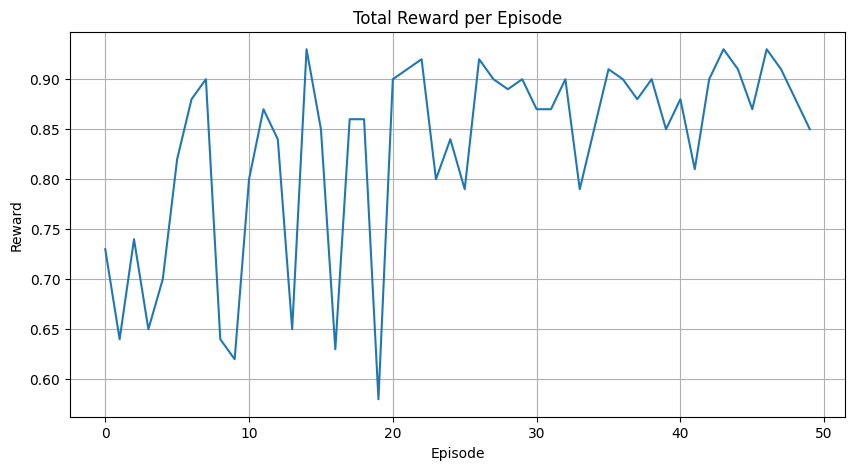

In [37]:

plt.figure(figsize=(10, 5))
plt.plot(reward_per_episode)
plt.title("Total Reward per Episode")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()


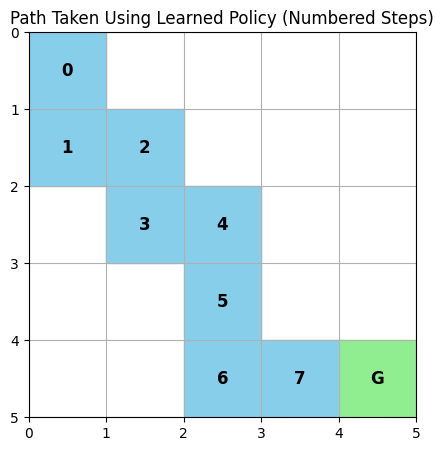

In [38]:
# Create visual trajectory using the arrow-based learned policy

def visualize_policy_path(policy_grid, start=(0, 0), goal=(4, 4), max_steps=25):
    path = [start]
    current_pos = start

    # Define direction mappings
    direction_map = {
        '↑': (-1, 0),
        '↓': (1, 0),
        '←': (0, -1),
        '→': (0, 1),
        'G': (0, 0)
    }

    for _ in range(max_steps):
        action_symbol = policy_grid[current_pos]
        if action_symbol == 'G':
            break

        move = direction_map[action_symbol]
        next_pos = (current_pos[0] + move[0], current_pos[1] + move[1])
        path.append(next_pos)
        current_pos = next_pos

        if current_pos == goal:
            break

    # Plot the grid with the path
    fig, ax = plt.subplots(figsize=(5, 5))
    grid_size = policy_grid.shape[0]

    ax.set_xlim(0, grid_size)
    ax.set_ylim(0, grid_size)
    ax.set_xticks(np.arange(0, grid_size + 1))
    ax.set_yticks(np.arange(0, grid_size + 1))
    ax.grid(True)
    ax.invert_yaxis()

    # Draw path
    for step, pos in enumerate(path):
        color = 'lightgreen' if pos == goal else 'skyblue'
        ax.add_patch(patches.Rectangle((pos[1], pos[0]), 1, 1, color=color))
        label = 'G' if pos == goal else str(step)
        ax.text(pos[1] + 0.5, pos[0] + 0.5, label, ha='center', va='center', fontsize=12, fontweight='bold')

    ax.set_title("Path Taken Using Learned Policy (Numbered Steps)")
    plt.show()

# Use the final policy grid from earlier
visualize_policy_path(policy_grid)



### 🔹 Final Q-Values Summary (After Training)

Below is a snapshot of the Q-values learned by the agent in the last episode.  
Each Q-value represents the agent’s estimation of the long-term reward for taking an action in a given state.  
There are 4 actions per state:  
- Index 0 → UP  
- Index 1 → DOWN  
- Index 2 → LEFT  
- Index 3 → RIGHT


In [39]:

# Show final Q-values for all directions from a few positions
for i in range(env.size):
    for j in range(env.size):
        print(f"Q-values at position ({i}, {j}): {q_table[i, j]}")


Q-values at position (0, 0): [-0.0248083  -0.02274967 -0.02367161 -0.02279155]
Q-values at position (0, 1): [-0.0170737  -0.01638877 -0.01866237 -0.01335774]
Q-values at position (0, 2): [-0.01213194  0.01030644 -0.01398988 -0.0106005 ]
Q-values at position (0, 3): [-0.00785098 -0.006956   -0.00785738 -0.00794926]
Q-values at position (0, 4): [-0.00495025  0.00196009 -0.00625512 -0.00580899]
Q-values at position (1, 0): [-0.01790559 -0.01642069 -0.01662612 -0.01634596]
Q-values at position (1, 1): [-0.01326737 -0.00464624 -0.01217641 -0.01166648]
Q-values at position (1, 2): [-0.0092552   0.08632831 -0.00766022 -0.00733174]
Q-values at position (1, 3): [-0.00510955  0.00714743 -0.00423632 -0.0016717 ]
Q-values at position (1, 4): [-0.00389392  0.09627283 -0.00479876 -0.0039701 ]
Q-values at position (2, 0): [-0.01157768 -0.0105518  -0.01167544 -0.01090677]
Q-values at position (2, 1): [-0.00767492 -0.00687843 -0.00960511  0.07704028]
Q-values at position (2, 2): [-0.00410343  0.3042414